In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

# Debug helper
DEBUG = True
def debug(msg):
    if DEBUG:
        print(f"[DEBUG] {msg}")

# Device setup for Apple MPS / CPU fallback
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
debug(f"Using device: {device}")


[DEBUG] Using device: mps


In [37]:
class CelebADatasetAug(Dataset):
    def __init__(self, img_folder, id_file, split_images, transform=None, augment=True):
        self.img_folder = img_folder
        self.id_map = pd.read_csv(id_file, sep=" ", header=None, names=["image", "identity"])
        self.id_map = self.id_map[self.id_map["image"].isin(split_images)]
        self.transform = transform
        self.augment = augment

        # Define augmentations
        self.augmentation_transforms = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.RandomResizedCrop(size=(224,224), scale=(0.8,1.0), ratio=(0.9,1.1)),
            transforms.ToTensor(),  # <-- make sure this is here
            transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
        ])

        debug(f"Dataset initialized with {len(self.id_map)} images")

    def __len__(self):
        return len(self.id_map)

    def __getitem__(self, idx):
        row = self.id_map.iloc[idx]
        img_path = os.path.join(self.img_folder, row["image"])
        image = Image.open(img_path).convert("RGB")
    
        if self.augment:
            # Augmentation + convert to tensor + normalize
            image = self.augmentation_transforms(image)
        elif self.transform:
            image = self.transform(image)
    
        label = torch.tensor(row["identity"], dtype=torch.long)
        return image, label


# Transforms
base_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

# Load split images
train_images = os.listdir("celeba_splits/train")
val_images = os.listdir("celeba_splits/val")
test_images = os.listdir("celeba_splits/test")

# Datasets
train_dataset = CelebADatasetAug("Celeba/img_align_celeba/img_align_celeba", "/Users/kousiknandury/Downloads/Celeba/identity_CelebA.txt",
                                 train_images, transform=base_transform, augment=True)
val_dataset = CelebADatasetAug("Celeba/img_align_celeba/img_align_celeba", "/Users/kousiknandury/Downloads/Celeba/identity_CelebA.txt",
                               val_images, transform=base_transform, augment=False)
test_dataset = CelebADatasetAug("Celeba/img_align_celeba/img_align_celeba", "/Users/kousiknandury/Downloads/Celeba/identity_CelebA.txt",
                                test_images, transform=base_transform, augment=False)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

debug(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


[DEBUG] Dataset initialized with 162770 images
[DEBUG] Dataset initialized with 19867 images
[DEBUG] Dataset initialized with 19962 images
[DEBUG] Train batches: 2544, Val batches: 311, Test batches: 312


In [39]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    model = model.to(device)
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, running_corrects, total = 0.0, 0, 0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)
            
            if i % 50 == 0:
                debug(f"[Epoch {epoch+1}] Batch {i} - approx memory: {images.element_size()*images.nelement()/1024/1024:.2f} MB")
        
        epoch_loss = running_loss / total
        epoch_acc = running_corrects / total * 100
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        debug(f"[Epoch {epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    
    # Plot loss & accuracy curves
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(range(1,num_epochs+1), train_losses, label="Train Loss")
    plt.plot(range(1,num_epochs+1), val_losses, label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curve"); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(range(1,num_epochs+1), train_accs, label="Train Acc")
    plt.plot(range(1,num_epochs+1), val_accs, label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.title("Accuracy Curve"); plt.legend()
    plt.show()

    return model

def evaluate(model, data_loader, criterion=None):
    model.eval()
    running_loss, running_corrects, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if criterion:
                loss = criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)
    acc = running_corrects / total * 100
    avg_loss = running_loss / total if criterion else 0.0
    return avg_loss, acc


[DEBUG] [DEBUG] SimpleCNN has 210817857 trainable parameters
[DEBUG] [Epoch 1] Batch 0 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 50 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 100 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 150 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 200 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 250 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 300 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 350 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 400 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 450 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 500 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 550 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 600 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 650 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 700 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 750 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 800 - approx memory: 36.75 MB
[DEBUG] [Epoch 1] Batch 

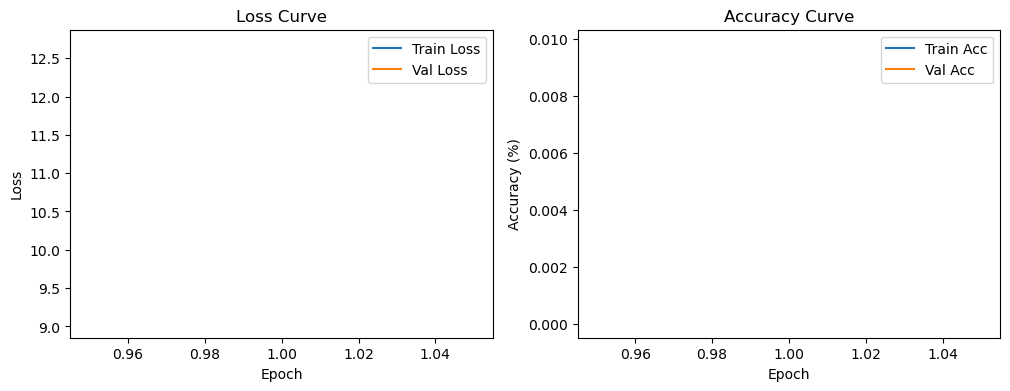

[DEBUG] SimpleCNN saved as simplecnn.pth


In [41]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128*56*56, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

num_classes = 10177
model_simple = SimpleCNN(num_classes)
debug(f"[DEBUG] SimpleCNN has {sum(p.numel() for p in model_simple.parameters() if p.requires_grad)} trainable parameters")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_simple.parameters(), lr=0.001)

# Train SimpleCNN
model_simple = train_model(model_simple, train_loader, val_loader, criterion, optimizer, num_epochs=1)

# Save model
torch.save(model_simple.state_dict(), "simplecnn.pth")
debug("SimpleCNN saved as simplecnn.pth")
